In [1]:
"""
The calculation of Volterra response is implemented up to the 5th order for non-causal systems
"""
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement, permutations
import plotly.graph_objects as go
from Volterra_In_Out_6 import VolterraResponse

n = 150 # Number of points
x1 = np.zeros(n) #Dirac delta function
x1[n//2] = 1
x2 = np.concatenate((np.zeros(n//2), np.ones(n//2))) #Step function
x3 = np.linspace(0, 1, n) #Ramp function
x4 = np.sin(np.linspace(0, 2*np.pi, n)) #Sin wave
x5 = np.sign(np.sin(np.linspace(0, 2*np.pi, n))) #Square wave
x6 = np.random.normal(0, 1, n) #White noise

# Plot all signals
signals = [x1, x2, x3, x4, x5, x6]
titles = ['Dirac Delta', 'Step', 'Ramp', 'Sin','Square', 'White Noise']


a1=10
a2=-0.5
a3=0.05
a4=-0.03
a5=90

x=x1
x_delay1 = np.concatenate(([0], x[:-1]))
x_delay2 = np.concatenate(([0, 0], x[:-2]))
x_delay3 = np.concatenate(([0, 0, 0], x[:-3]))
x_delay4 = np.concatenate(([0, 0, 0, 0], x[:-4]))
#finish this
y_dynamic = a1*x + a2*x_delay1*x_delay2 + a3*x_delay2*x_delay3*x_delay4 + a4*x_delay1*x_delay3*x_delay4*x_delay4 + a5*x_delay1*x_delay2*x_delay3*x_delay4*x_delay4

v= VolterraResponse()
v.h1 = a1
v.h2[1,2] = a2/2
v.h3[2,3,4] = a3/6
v.h4[1,3,4,4] = a4/24
v.h5[1,2,3,4,4] = a5/120

v_out= v.Volterra_In_Out(x)
v_real= y_dynamic

plt.figure()
plt.plot(v_out, label='Volterra')
plt.plot(v_real, label='Real')
plt.legend()
plt.show()



Using device: NVIDIA GeForce RTX 3060 Ti, Type: ALL | GPU
  Device: NVIDIA GeForce RTX 3060 Ti
    Type: ALL | GPU
    Version: OpenCL 3.0 CUDA
    Vendor: NVIDIA Corporation
    Global Memory Size: 7966 MB
    Local Memory Size: 48 KB
    Max Compute Units: 38
    Max Work Group Size: 1024
    Max Work Item Dimensions: 3
    Max Work Item Sizes: [1024, 1024, 64]


/home/mrani/.local/lib/python3.11/site-packages/pyopencl/cache.py:495: CompilerWarning: Built kernel retrieved from cache. Original from-source build had warnings:
Build on <pyopencl.Device 'NVIDIA GeForce RTX 3060 Ti' on 'NVIDIA CUDA' at 0x55dc5216b390> succeeded, but said:

(): Warning: Function volterraH1 is a kernel, so overriding noinline attribute. The function may be inlined when called.
(): Warning: Function volterraH2 is a kernel, so overriding noinline attribute. The function may be inlined when called.
(): Warning: Function volterraH3 is a kernel, so overriding noinline attribute. The function may be inlined when called.
(): Warning: Function volterraH4 is a kernel, so overriding noinline attribute. The function may be inlined when called.
(): Warning: Function volterraH5 is a kernel, so overriding noinline attribute. The function may be inlined when called.


  _create_built_program_from_source_cached(


TypeError: object of type 'int' has no len()

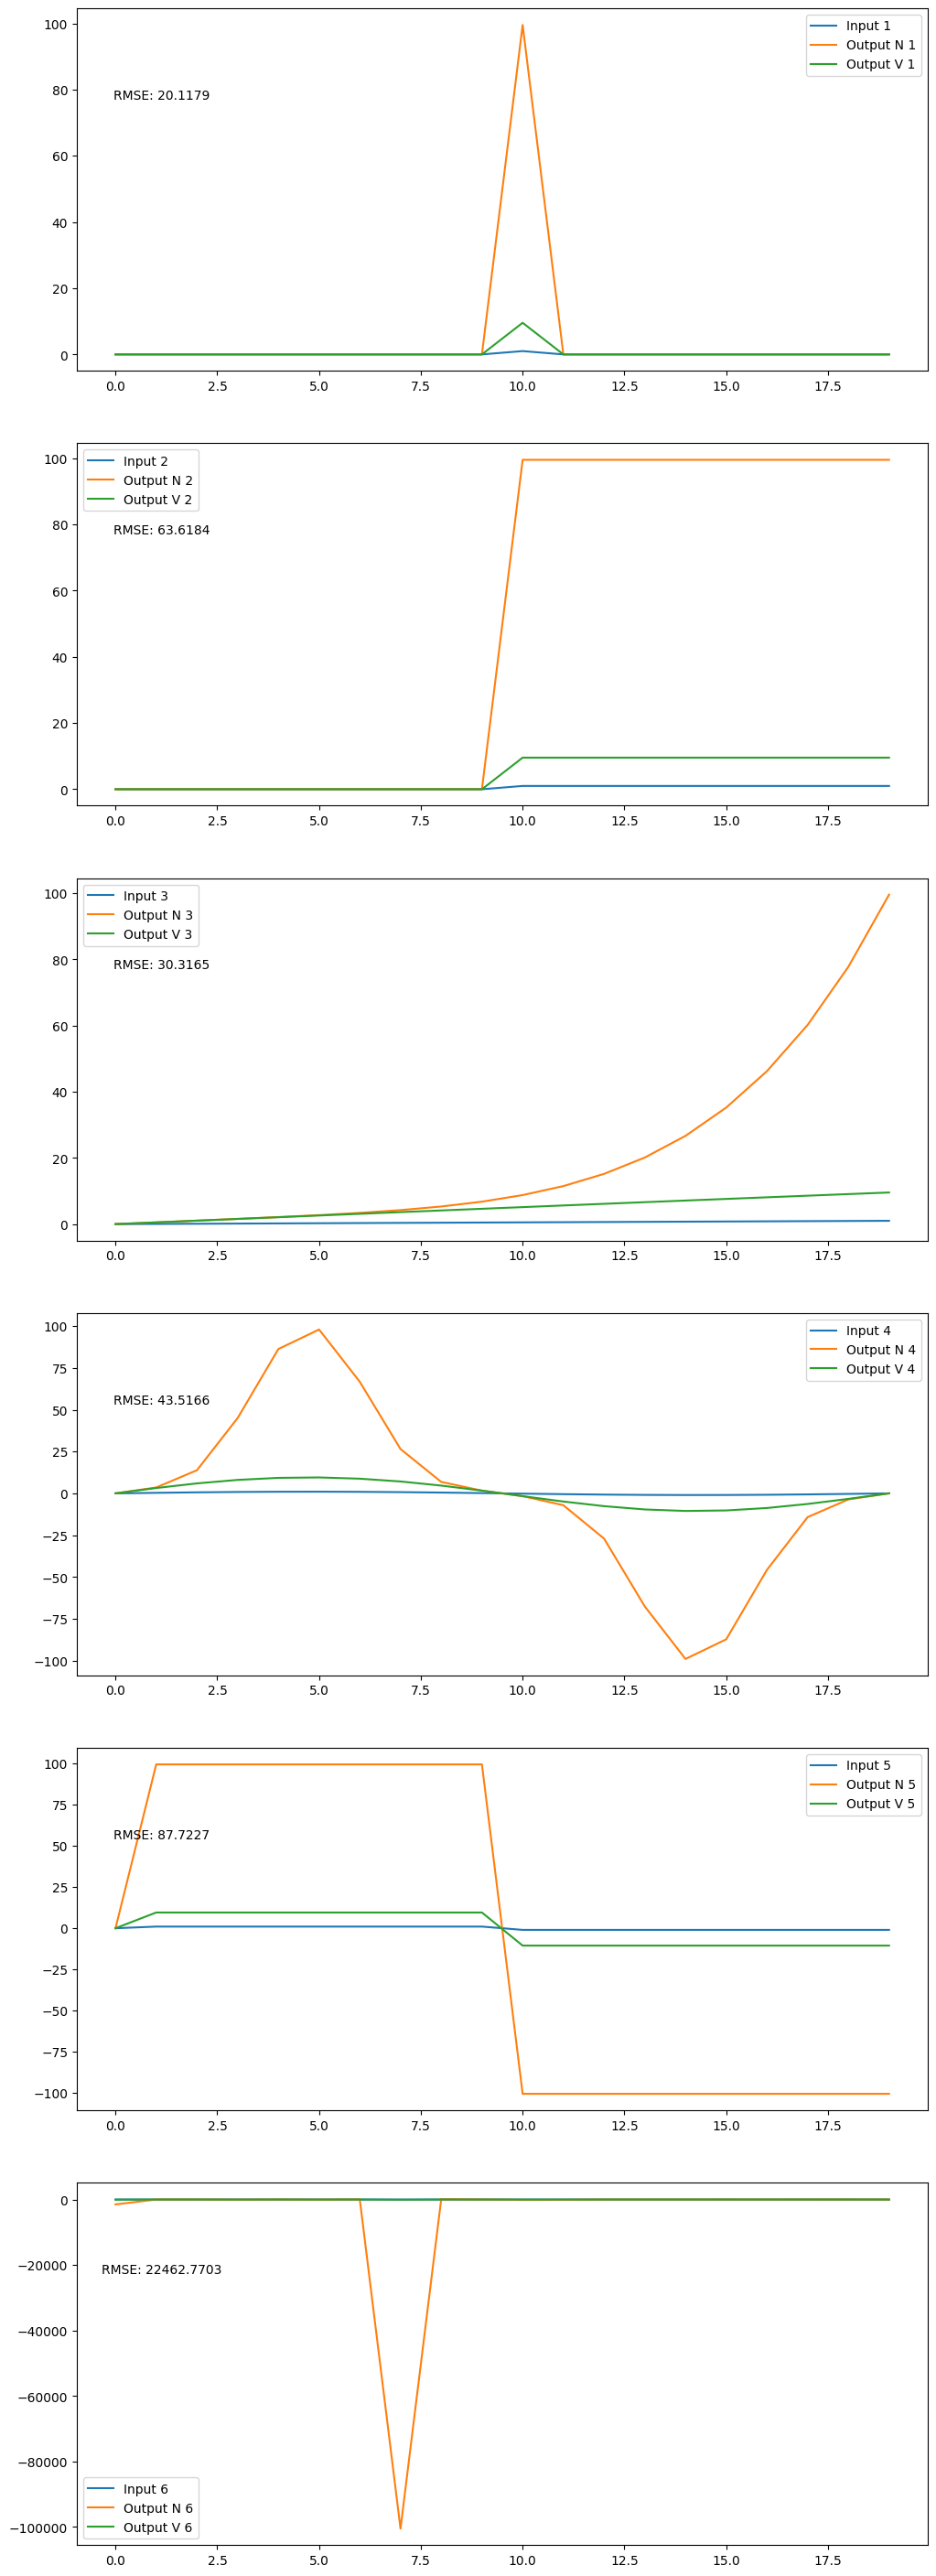

In [2]:




V_static = VolterraResponse(kernelName="Volterra_static")

V_static.h1[0] = a1
V_static.h2[0, 0] = a2
V_static.h3[0, 0, 0] = a3
# V_static.h4[0, 0, 0, 0] = a4
# V_static.h5[0, 0, 0, 0, 0] = a5


fig, axs = plt.subplots(len(signals), figsize=(12, 6*len(signals)))
for i, signal in enumerate(signals):
    response_N = static_real(signal)
    response_V = V_static.Volterra_In_Out(signal, 1, 0)

    # mean square error
    mse = np.mean((response_N - response_V)**2)
    
    # root mean square error
    rmse = np.sqrt(mse)
    
    axs[i].plot(signal, label=f'Input {i+1}')
    axs[i].plot(response_N, label=f'Output N {i+1}')
    axs[i].plot(response_V, label=f'Output V {i+1}')
    axs[i].legend()
    
    axs[i].text(0.1, 0.75, f'RMSE: {rmse:.4f}', transform=axs[i].transAxes, ha='center')
    
plt.show()

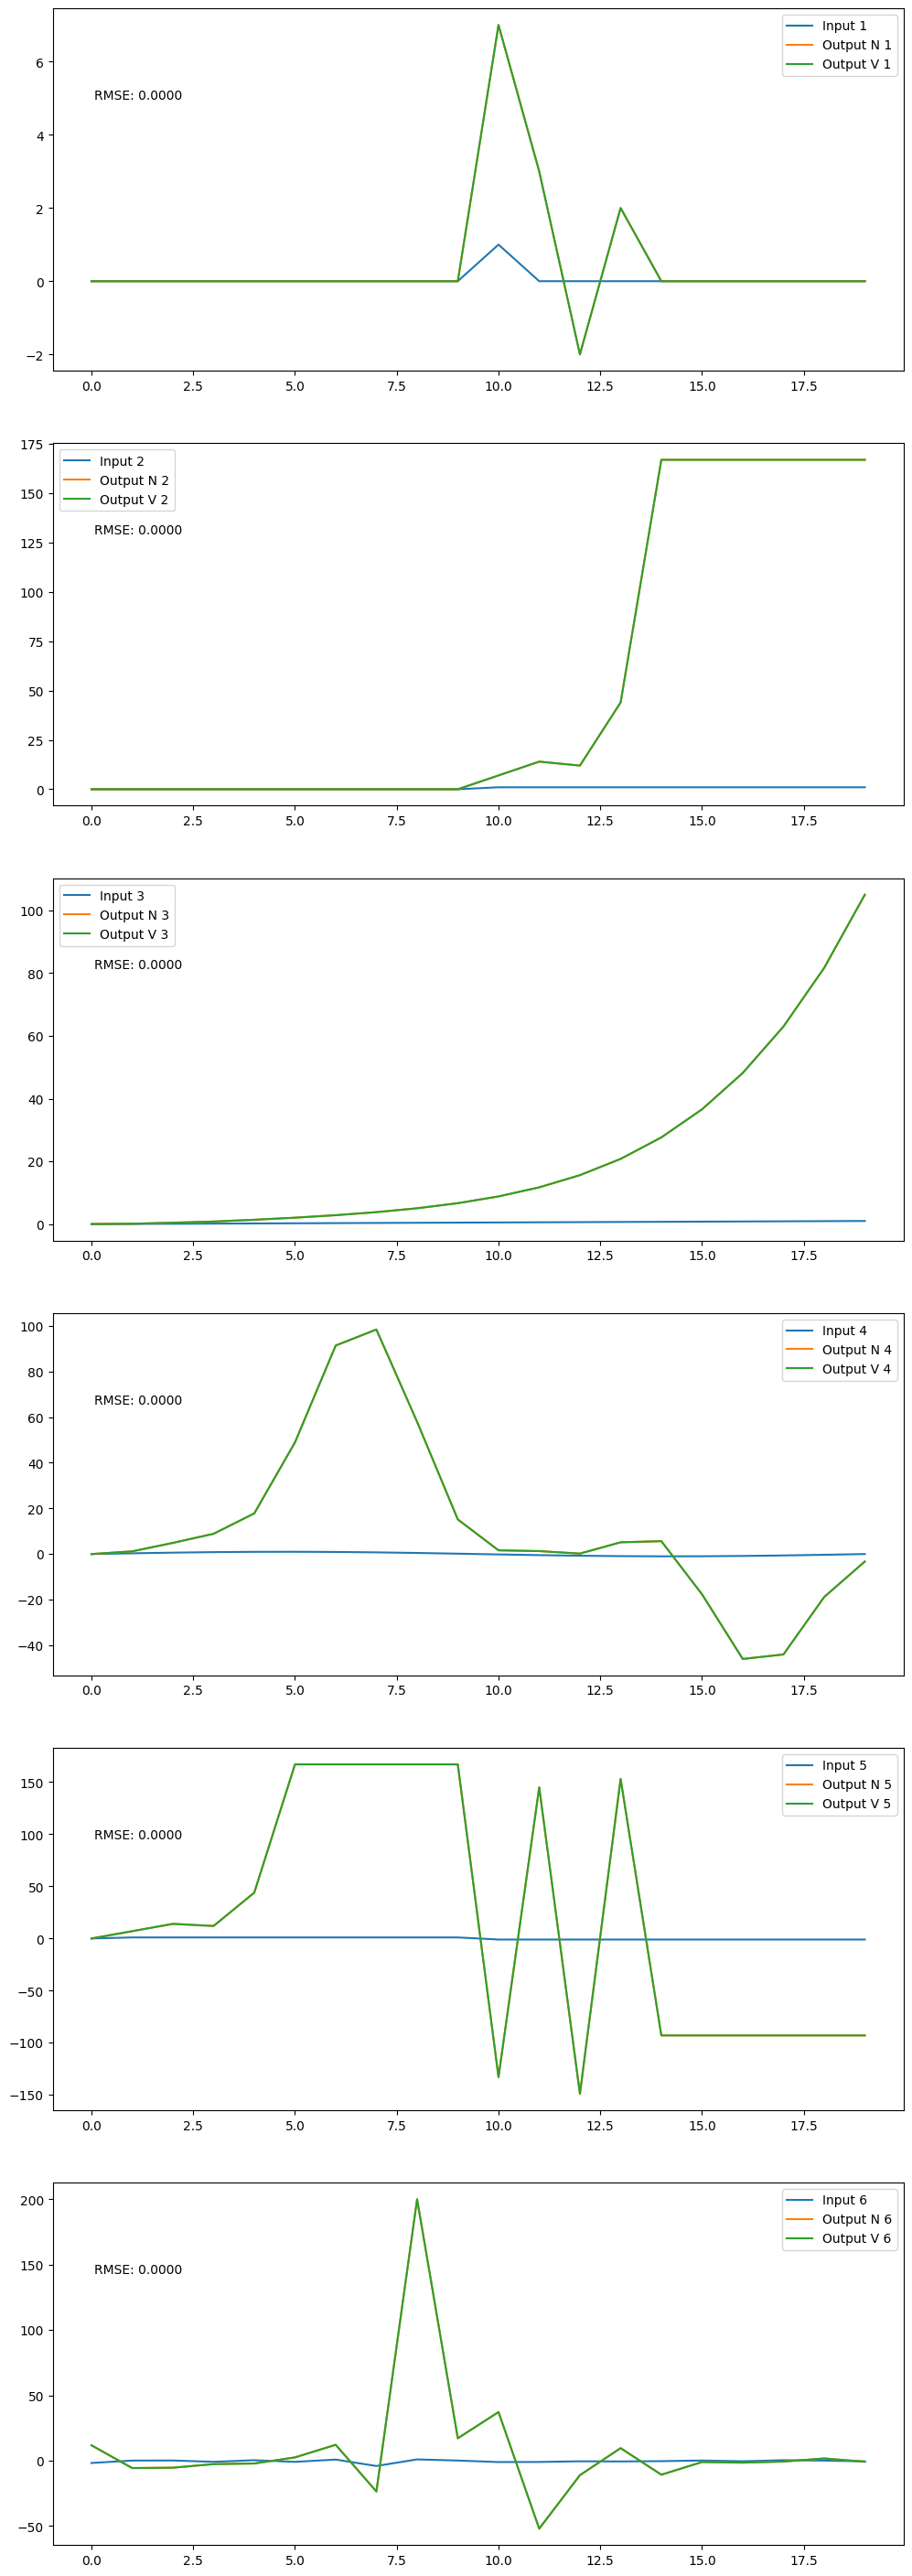

In [3]:
def calculate_response_2(x):
    x_delay1 = np.concatenate(([0], x[:-1]))
    x_delay2 = np.concatenate(([0, 0], x[:-2]))
    x_delay3 = np.concatenate(([0, 0, 0], x[:-3]))
    x_delay4 = np.concatenate(([0, 0, 0, 0], x[:-4]))
    y = 2*x + 5*x**2 + 3*x_delay1 + 4*x_delay1*x + 3*x_delay2*x_delay3*x_delay4 - 2*x_delay2**2 + 2*x_delay3 + 6*x_delay3*x_delay1 + 24*x*x_delay1*x_delay2*x_delay3 + 120*x*x_delay1*x_delay2*x_delay3*x_delay4
    return y

system2 = VolterraResponse(kernelName="system2")

system2.h1[0] = 2
system2.h1[1] = 3
system2.h1[3] = 2
system2.h2[0,0] = 5
system2.h2[1,0] = 2
system2.h2[2,2] = -2
system2.h2[3,1] = 3
system2.h2[0,1] = 2  
system2.h2[1,3] = 3  
system2.h3[2,3,4] = 0.5
system2.h3[4,3,2] = 0.5
system2.h3[3,2,4] = 0.5
system2.h3[4,2,3] = 0.5
system2.h3[2,4,3] = 0.5
system2.h3[3,4,2] = 0.5


# def calculate_response_2(x):
#     x_delay1 = np.concatenate(([0], x[:-1]))
#     x_delay2 = np.concatenate(([0, 0], x[:-2]))
#     x_delay3 = np.concatenate(([0, 0, 0], x[:-3]))
#     x_delay4 = np.concatenate(([0, 0, 0, 0], x[:-4]))
#     y = 10*x + 30*x_delay1 + 20*x_delay3
#     return y

# system2 = VolterraResponse(kernelName="system2")

# system2.h1[0] = 10
# system2.h1[1] = 30
# system2.h1[3] = 20
# system2.h2[0,0] = 5
# system2.h2[1,0] = 2
# system2.h2[2,2] = -2
# system2.h2[3,1] = 3
# system2.h2[0,1] = 2  
# system2.h2[1,3] = 3  
# system2.h3[2,3,4] = 0.5
# system2.h3[4,3,2] = 0.5
# system2.h3[3,2,4] = 0.5
# system2.h3[4,2,3] = 0.5
# system2.h3[2,4,3] = 0.5
# system2.h3[3,4,2] = 0.5

# 4th order kernel 24 permutations
indices = [0, 1, 2, 3]
for perm in permutations(indices):
    system2.h4[perm] = 1

# 5th order kernel 120 permutations
indices = [0, 1, 2, 3, 4]
for perm in permutations(indices):
    system2.h5[perm] = 1


fig, axs = plt.subplots(len(signals), figsize=(12, 6*len(signals)))
for i, signal in enumerate(signals):
    response_N = calculate_response_2(signal)
    response_V = system2.Volterra_In_Out(signal, 1, 0)

    # mean square error
    mse = np.mean((response_N - response_V)**2)
    
    # root mean square error
    rmse = np.sqrt(mse)
    
    axs[i].plot(signal, label=f'Input {i+1}')
    axs[i].plot(response_N, label=f'Output N {i+1}')
    axs[i].plot(response_V, label=f'Output V {i+1}')
    axs[i].legend()
    
    axs[i].text(0.1, 0.75, f'RMSE: {rmse:.4f}', transform=axs[i].transAxes, ha='center')
    
plt.show()



In [4]:
import autograd.numpy as np
from autograd import grad

def objective_function(flattened_kernels, x, y_true, volterra_model):
    num_h1 = 20
    num_h2 = 20*20
    num_h3 = 20*20*20
    num_h4 = 20*20*20*20
    num_h5 = 20*20*20*20*20
    
    idx_h2 = num_h1
    idx_h3 = idx_h2 + num_h2
    idx_h4 = idx_h3 + num_h3
    idx_h5 = idx_h4 + num_h4
    
    h1 = flattened_kernels[:num_h1]
    h2 = flattened_kernels[idx_h2:idx_h3].reshape(20, 20)
    h3 = flattened_kernels[idx_h3:idx_h4].reshape(20, 20, 20)
    h4 = flattened_kernels[idx_h4:idx_h5].reshape(20, 20, 20, 20)
    h5 = flattened_kernels[idx_h5:].reshape(20, 20, 20, 20, 20)
    
    volterra_model.h1 = h1
    volterra_model.h2 = h2
    volterra_model.h3 = h3
    volterra_model.h4 = h4
    volterra_model.h5 = h5
    
    y_pred = volterra_model.Volterra_In_Out(x)
    
    mse = np.mean((y_pred - y_true) ** 2)
    
    return mse

initial_h1 = np.random.randn(20)
initial_h2 = np.random.randn(20, 20).flatten()
initial_h3 = np.random.randn(20, 20, 20).flatten()
initial_h4 = np.random.randn(20, 20, 20, 20).flatten()
initial_h5 = np.random.randn(20, 20, 20, 20, 20).flatten()

initial_flattened_kernels = np.concatenate([initial_h1, initial_h2, initial_h3, initial_h4, initial_h5])

x = np.random.randn(1000)
y_true = np.random.randn(1000)

volterra_model = VolterraResponse()

objective_function_grad = grad(objective_function)

flattened_kernels = initial_flattened_kernels

learning_rate = 0.01
iterations = 1000

for _ in range(iterations):
    grad = objective_function_grad(flattened_kernels, x, y_true, volterra_model)
    flattened_kernels -= learning_rate * grad

ModuleNotFoundError: No module named 'autograd'

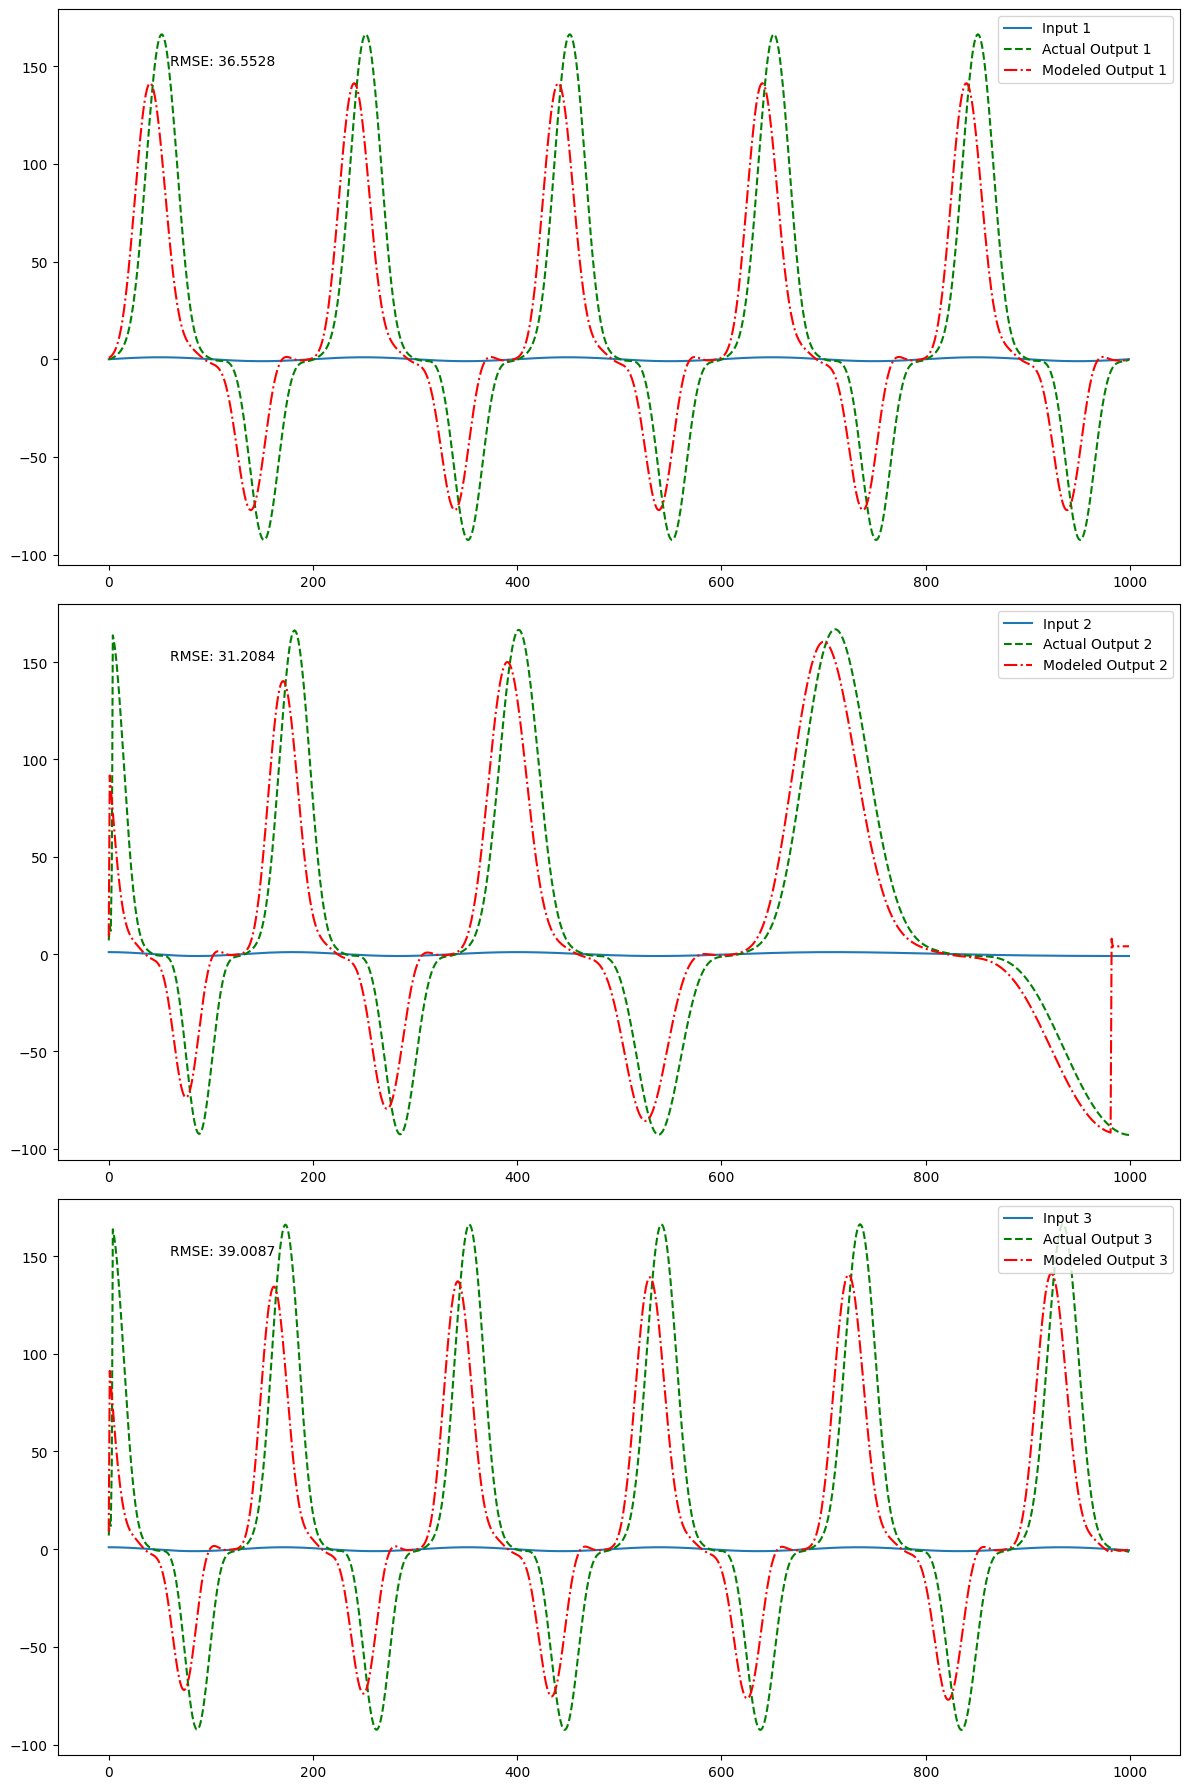

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations
from scipy.signal import chirp, sweep_poly
#input signals
t = np.linspace(0, 1, 1000)
signal1 = np.sin(2 * np.pi * 5 * t)  # Sine wave
signal2 = chirp(t, f0=6, f1=1, t1=1, method='linear')  # Chirp signal
signal3 = sweep_poly(t, [1, -2, 6])  # Polynomial sweep
signals = [signal1, signal2, signal3]

def calculate_response_2(x):
    x_delay1 = np.concatenate(([0], x[:-1]))
    x_delay2 = np.concatenate(([0, 0], x[:-2]))
    x_delay3 = np.concatenate(([0, 0, 0], x[:-3]))
    x_delay4 = np.concatenate(([0, 0, 0, 0], x[:-4]))
    y = 2*x + 5*x**2 + 3*x_delay1 + 4*x_delay1*x + 3*x_delay2*x_delay3*x_delay4 - 2*x_delay2**2 + 2*x_delay3 + 6*x_delay3*x_delay1 + 24*x*x_delay1*x_delay2*x_delay3 + 120*x*x_delay1*x_delay2*x_delay3*x_delay4
    return y

fig, axs = plt.subplots(len(signals), figsize=(12, 6*len(signals)))

for i, signal in enumerate(signals):
    response_N = calculate_response_2(signal)
    response_V = system2.Volterra_In_Out(signal, 1, 18)

    mse = np.mean((response_N - response_V)**2)
    rmse = np.sqrt(mse)
    
    axs[i].plot(signal, label=f'Input {i+1}')
    axs[i].plot(response_N, 'g--', label=f'Actual Output {i+1}')
    axs[i].plot(response_V, 'r-.', label=f'Modeled Output {i+1}')
    axs[i].legend(loc='upper right')
    
    # Displaying RMSE on the plot
    axs[i].text(0.1, 0.9, f'RMSE: {rmse:.4f}', transform=axs[i].transAxes)

plt.tight_layout()
plt.show()


[3. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


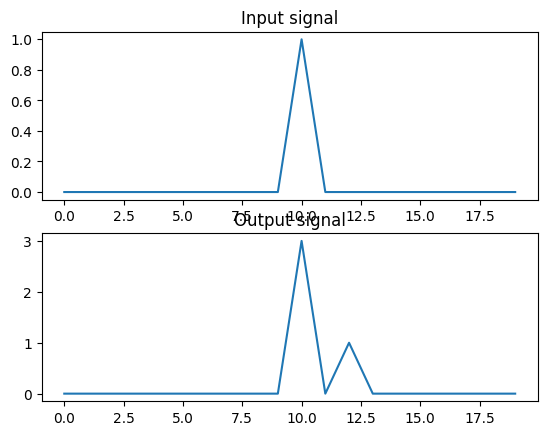

In [ ]:
x = np.zeros(n)
x[n//2] = 1

h1 = np.zeros(20)
h2 = np.zeros((20,20))
h3 = np.zeros((20,20,20))
h4 = np.zeros((20,20,20,20))
h5 = np.zeros((20,20,20,20,20))

h1[-5] = 1
h1[0]= 3
h1[2] = 1

h2[-5,-5] = 1
h2[0,0] = 3
h2[2,2] = 1

h3[-5,-5,-5] = 1
h3[0,0,0] = 3
h3[2,2,2] = 1
print(h1)
volterra = VolterraResponse()
volterra.h1 = h1
volterra.h2 = h2
volterra.h3 = h3
volterra.h4 = h4
volterra.h5 = h5

y = volterra.H3(x,1,4)

plt.figure()
plt.subplot(2, 1, 1)
plt.plot(x)
plt.title('Input signal')
plt.subplot(2, 1, 2)
plt.plot(y)
plt.title('Output signal')
plt.show()